# Технологии Машинного Обучения. РК1
## Чернев Н.А. ИУ5-64Б
### Вариант 20(3, 4)

### Задача
Для заданного набора данных произведите масштабирование данных (для одного признака) и преобразование категориальных признаков в количественные двумя способами (label encoding, one hot encoding) для одного признака. Какие методы Вы использовали для решения задачи и почему?


In [55]:
import pandas as pd
import matplotlib.pyplot as plt


# df = pd.read_csv('https://raw.githubusercontent.com/colan1ch/Datasets/refs/heads/main/toy/toy_dataset.csv')
df = pd.read_csv('/Users/nachernev/Desktop/Datasets/toy/toy_dataset.csv')
df

,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No
...,...,...,...,...,...,...
149995,149996,Austin,Male,48,93669.0,No
149996,149997,Austin,Male,25,96748.0,No
149997,149998,Austin,Male,26,111885.0,No
149998,149999,Austin,Male,25,111878.0,No


In [56]:
df.select_dtypes(include=['number']).columns

Index(['Number', 'Age', 'Income'], dtype='object')

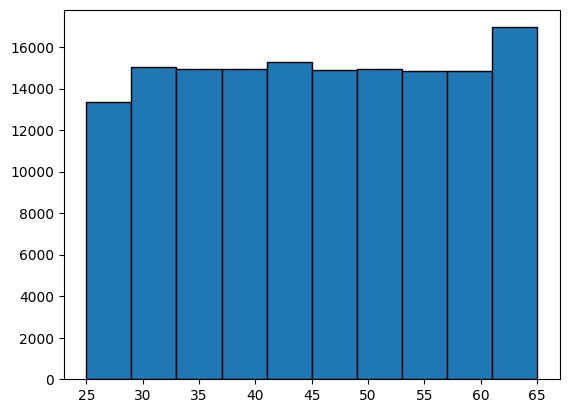

In [57]:
plt.hist(df['Age'], edgecolor='black')
plt.show()

In [58]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np


s = MinMaxScaler()
df['Age'] = s.fit_transform(np.array(df['Age']).reshape(-1, 1))
df['Age']

0         0.400
1         0.725
2         0.425
3         0.375
4         0.525
          ...  
149995    0.575
149996    0.000
149997    0.025
149998    0.000
149999    0.300
Name: Age, Length: 150000, dtype: float64

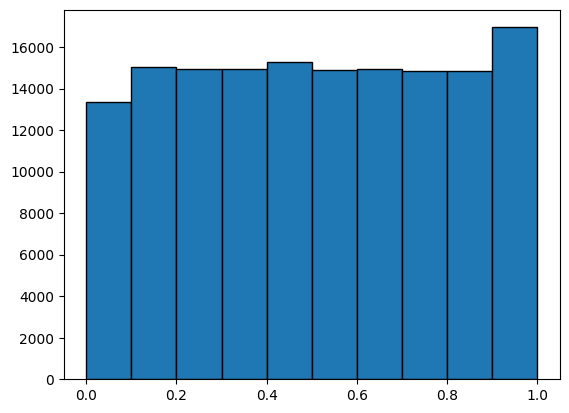

In [59]:
plt.hist(df['Age'], edgecolor='black')
plt.show()

In [60]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder


le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

ohe = OneHotEncoder(sparse_output=False)
cities = ohe.fit_transform(df[['City']])
city_columns = ohe.get_feature_names_out(['City'])
df_city = pd.DataFrame(cities, columns=city_columns, index=df.index)
df = pd.concat([df, df_city], axis=1).drop('City', axis=1)
df

,Number,Gender,Age,Income,Illness,City_Austin,City_Boston,City_Dallas,City_Los Angeles,City_Mountain View,City_New York City,City_San Diego,City_Washington D.C.
0,1,1,0.400,40367.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,1,0.725,45084.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,1,0.425,52483.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,1,0.375,40941.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,1,0.525,50289.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,1,0.575,93669.0,No,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
149996,149997,1,0.000,96748.0,No,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
149997,149998,1,0.025,111885.0,No,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
149998,149999,1,0.000,111878.0,No,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **Использованные методы и инструменты:**

1. **Масштабирование данных:**
   - **MinMaxScaler** из `sklearn.preprocessing` для признака `Age`
   - Данные приведены в диапазон [0, 1] с помощью формулы: (x - min) / (max - min)
   - Причина выбора: сохраняет форму распределения, приносит все значения в одинаковый масштаб, хорош для алгоритмов, чувствительных к величине признаков (нейросети, KNN)

2. **Label Encoding:**
   - **LabelEncoder** из `sklearn.preprocessing` для категориального признака `Gender`
   - Преобразование: Male → 1, Female → 0
   - Причина: для бинарных признаков с естественной иерархией - минимизирует размерность

3. **One-Hot Encoding:**
   - **OneHotEncoder** из `sklearn.preprocessing` для категориального признака `City`
   - Создано 8 бинарных признаков (Austin, Boston, Dallas, Los Angeles, Mountain View, New York City, San Diego, Washington D.C.)
   - Причина: для номинальных признаков без порядка - избегает арифметической интерпретации